In [1]:
import ir_datasets

all_datasets = [name for name in ir_datasets.registry._registered.keys() if 'tot' in name.lower()]
print(all_datasets)

['trec-tot', 'trec-tot/2023', 'trec-tot/2023/train', 'trec-tot/2023/dev', 'trec-tot/2024', 'trec-tot/2024/test', 'trec-tot/2025', 'trec-tot/2025/train', 'trec-tot/2025/dev1', 'trec-tot/2025/dev2', 'trec-tot/2025/dev3']


In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import os
os.environ['CURL_CA_BUNDLE'] = ''
os.environ['REQUESTS_CA_BUNDLE'] = ''


In [3]:
import ir_datasets

dataset_train = ir_datasets.load("trec-tot/2023/train")
dataset_dev = ir_datasets.load("trec-tot/2023/dev")
dataset_test = ir_datasets.load("trec-tot/2024/test")

#checking for the first query
for query in dataset_train.queries_iter():
    print(query)
    break

TipOfTheTongueQuery(query_id='763', url='https://irememberthismovie.com/super-rare-surreal-dystopian-masterpiece/', domain='movie', title='Super Rare Surreal Dystopian Masterpiece', text='Very rare movie that is scifi/dystopian/experimental/surreal. It’s like Stalker meets el Topo meets Holy Mountain meets Alphaville meets Delicatessen meets Hard to be a God, like Kurosawa, Tarkovsky, and Lynch had a kid together. It was color, possibly Russian, and I don’t really remember the decade but want to say 60s or 70s, though could easily be more recent. It is VERY rare, there is only one crappy partial print of it, and that is what the youtube version is from. Lot of wide shots in a surreal wilderness, winter settings, strange bleeding saturation in some shots. Crazy costumes. Seriously one of the strangest films I’ve ever seen and my favorite films are strange/weird ones. If you’ve ever seen what you’re thinking of on a “best weird movies” or “you’ve never seen this!” list, that’s NOT it. I 

In [4]:
for q in dataset_test.queries_iter():
    print(q._fields)  #show available variables
    print(q)
    break

('query_id', 'query')
TipOfTheTongueQuery2024(query_id='2001', query="I remember this old building I used to pass by in the heart of a bustling financial district, a place where the air always seemed thick with the scent of ambition and old money. The building itself was quite striking, with a facade that looked like it was carved out of some kind of pale stone, maybe marble? It had this grand, almost imposing presence, like it was watching over the street with a stern, unyielding gaze.  I think it was only a few stories tall, but it had this grand entrance that made it feel much larger than it actually was. The first floor was particularly memorable, almost like it was designed to be the most impressive part of the building. There were these large windows that seemed to peer out over the street, giving it a sense of openness despite its age.  I remember hearing stories about some kind of explosion or attack that happened there a long time ago, and they never really fixed the damage. I

In [5]:
#for train
for q in dataset_train.queries_iter():
    print("TRAIN fields:", q._fields)
    break

#for dev
for q in dataset_dev.queries_iter():
    print("DEV fields:", q._fields)
    break

#for test
for q in dataset_test.queries_iter():
    print("TEST fields:", q._fields)
    break

TRAIN fields: ('query_id', 'url', 'domain', 'title', 'text', 'sentence_annotations')
DEV fields: ('query_id', 'url', 'domain', 'title', 'text', 'sentence_annotations')
TEST fields: ('query_id', 'query')


In [6]:
import pandas as pd

def queries_to_df(dataset, has_annotations=True):
    rows = []
    for q in dataset.queries_iter():
        if has_annotations:
            text = q.text
            row = {
                "query_id": q.query_id,
                "domain": q.domain,
                "title": q.title,
                "text": text,
                "num_words": len(text.split()),
                "num_chars": len(text),
                "num_sentences": len(q.sentence_annotations),
                "has_hedging": any(s['labels']['hedging'] for s in q.sentence_annotations),
                "has_negation": any(s['labels']['movie']['negation'] for s in q.sentence_annotations),
                "has_opinion": any(s['labels']['opinion'] for s in q.sentence_annotations),
                "has_comparison": any(s['labels']['comparison_relative'] for s in q.sentence_annotations),
            }
        else:
            text = q.query
            row = {
                "query_id": q.query_id,
                "text": text,
                "num_words": len(text.split()),
                "num_chars": len(text),
            }
        rows.append(row)
    return pd.DataFrame(rows)

df_train = queries_to_df(dataset_train, has_annotations=True)
df_dev = queries_to_df(dataset_dev, has_annotations=True)
df_test = queries_to_df(dataset_test, has_annotations=False)

print("train:", len(df_train), "query")
print("dev:", len(df_dev), "query")
print("test:", len(df_test), "query")
df_train.head()

train: 150 query
dev: 150 query
test: 600 query


,query_id,domain,title,text,num_words,num_chars,num_sentences,has_hedging,has_negation,has_opinion,has_comparison
0,763,movie,Super Rare Surreal Dystopian Masterpiece,Very rare movie that is scifi/dystopian/experi...,188,1090,12,True,False,True,True
1,802,movie,Male little person falls in love with red-head...,I hope someone can help me track down this mov...,221,1175,15,True,False,False,False
2,950,movie,Movie about two girls who run away and murder ...,"I’m not sure if this is even a movie, a tv sho...",165,821,6,True,False,False,False
3,220,movie,Possibly an occult film,"I remember I was yiunger when I saw it, but I ...",103,537,5,True,False,False,False
4,792,movie,kid who robs houses,"Ok, so I seen this movie about 10 or so years ...",104,525,6,True,False,False,False


In [7]:
#EDA

import matplotlib.pyplot as plt
import seaborn as sns

#combine all annotated queries
df_all = pd.concat([df_train, df_dev], ignore_index=True)

print("GENERAL STATISTICS")
print(f"total query count (train+dev):  {len(df_all)}")

print(f"test query count (train+dev):  {len(df_test)}")

print("WORD COUNT")
print(df_all['num_words'].describe().round(2))

print("SENTENCE COUNT")
print(df_all['num_sentences'].describe().round(2))

print("DOMAIN DISTRIBUTION")
print(df_all['domain'].value_counts())

print("ANNOTATION DISTRIBUTION ")
print(f"has hedging: {df_all['has_hedging'].sum()} ({df_all['has_hedging'].mean()*100:.1f}%)")
print(f"has negation: {df_all['has_negation'].sum()} ({df_all['has_negation'].mean()*100:.1f}%)")
print(f"has opinion: {df_all['has_opinion'].sum()} ({df_all['has_opinion'].mean()*100:.1f}%)")
print(f"has comparison: {df_all['has_comparison'].sum()} ({df_all['has_comparison'].mean()*100:.1f}%)")

GENERAL STATISTICS
total query count (train+dev):  300
test query count (train+dev):  600
WORD COUNT
count    300.00
mean     135.03
std       77.05
min        8.00
25%       84.75
50%      113.50
75%      171.00
max      546.00
Name: num_words, dtype: float64
SENTENCE COUNT
count    300.00
mean       7.85
std        4.74
min        1.00
25%        4.75
50%        7.00
75%       10.00
max       29.00
Name: num_sentences, dtype: float64
DOMAIN DISTRIBUTION
domain
movie    300
Name: count, dtype: int64
ANNOTATION DISTRIBUTION 
has hedging: 274 (91.3%)
has negation: 19 (6.3%)
has opinion: 36 (12.0%)
has comparison: 59 (19.7%)


In [15]:
#PLOTS

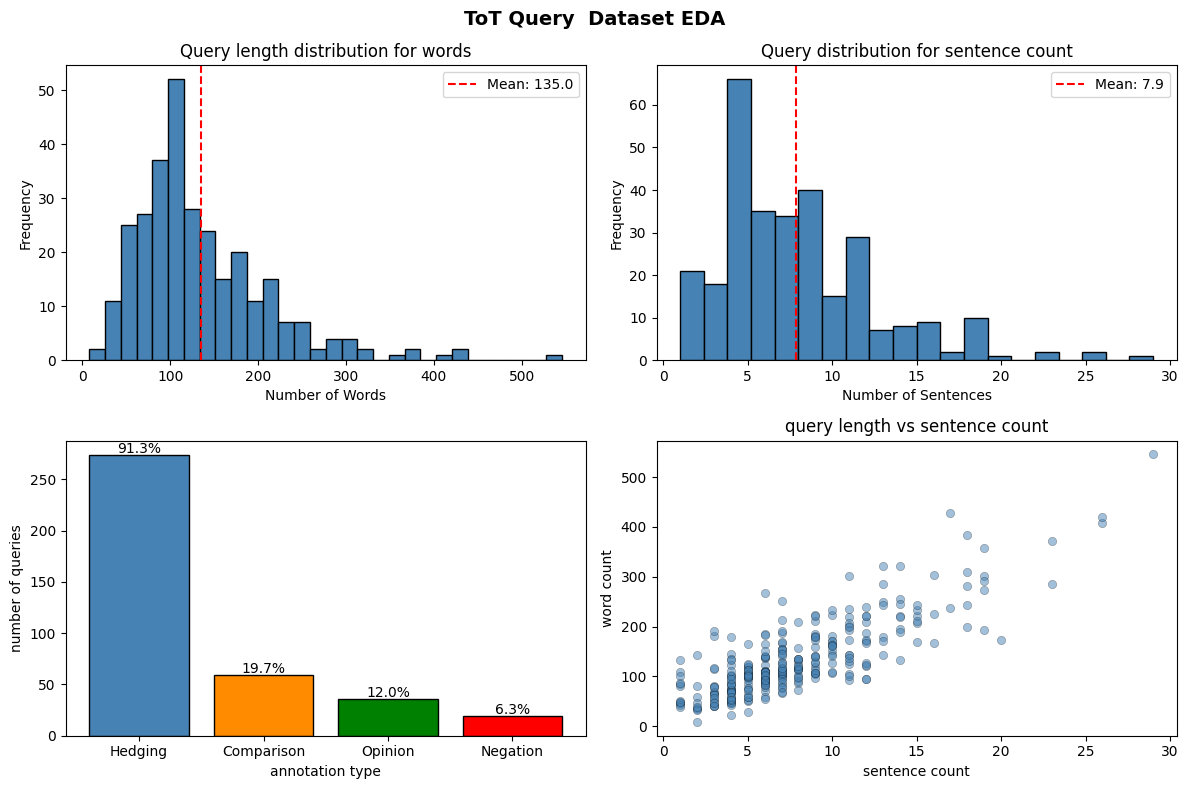

saved: C:\Users\ozgu.ozkan\Desktop\termProjectNLP\figures


In [8]:
#saving dir
figures_dir = r"C:\Users\ozgu.ozkan\Desktop\termProjectNLP\figures"
os.makedirs(figures_dir, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12,8))
fig.suptitle('ToT Query  Dataset EDA', fontsize = 14, fontweight='bold')

#word count dist
axes[0, 0].hist(df_all['num_words'], bins = 30, color='steelblue', edgecolor='black')
axes[0, 0].axvline(df_all['num_words'].mean(), color = 'red', linestyle='--', label=f"Mean: {df_all['num_words'].mean():.1f}")
axes[0, 0].set_xlabel('Number of Words')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Query length distribution for words')
axes[0, 0].legend()

#sentence count dist
axes[0, 1].hist(df_all['num_sentences'], bins=20, color='steelblue', edgecolor='black')
axes[0, 1].axvline(df_all['num_sentences'].mean(), color='red', linestyle='--', label=f"Mean: {df_all['num_sentences'].mean():.1f}")
axes[0, 1].set_xlabel('Number of Sentences')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Query distribution for sentence count')
axes[0, 1].legend()

#annot dist
annotation_counts = {
    'Hedging': df_all['has_hedging'].sum(),
    'Comparison': df_all['has_comparison'].sum(),
    'Opinion': df_all['has_opinion'].sum(),
    'Negation': df_all['has_negation'].sum(),
}
axes[1, 0].bar(annotation_counts.keys(), annotation_counts.values(), color=['steelblue', 'darkorange', 'green', 'red'], edgecolor='black')
axes[1, 0].set_xlabel('annotation type')
axes[1, 0].set_ylabel('number of queries')
for i, (k, v) in enumerate(annotation_counts.items()):
    axes[1, 0].text(i, v+2, f'{v/len(df_all)*100:.1f}%', ha='center', fontsize=10)

#word count and sentence count SCATTER PLOT
axes[1, 1].scatter(df_all['num_sentences'], df_all['num_words'],
                   alpha=0.5, color='steelblue', edgecolor='black', linewidth=0.3)
axes[1, 1].set_xlabel('sentence count')
axes[1, 1].set_ylabel('word count')
axes[1, 1].set_title('query length vs sentence count')


plt.tight_layout()


plt.savefig(os.path.join(figures_dir, 'eda_queries.svg'), format='svg', bbox_inches='tight')
plt.savefig(os.path.join(figures_dir, 'eda_queries.pdf'), format='pdf', bbox_inches='tight')
plt.show()

print("saved:", figures_dir)

In [9]:
import os
print(os.getcwd())

C:\Users\ozgu.ozkan\Desktop


In [26]:
pip install plotly wordcloud

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.9 MB 16.2 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.9 MB 13.6 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 13.2 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 5.7 MB/s  0:00:01

   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   --


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


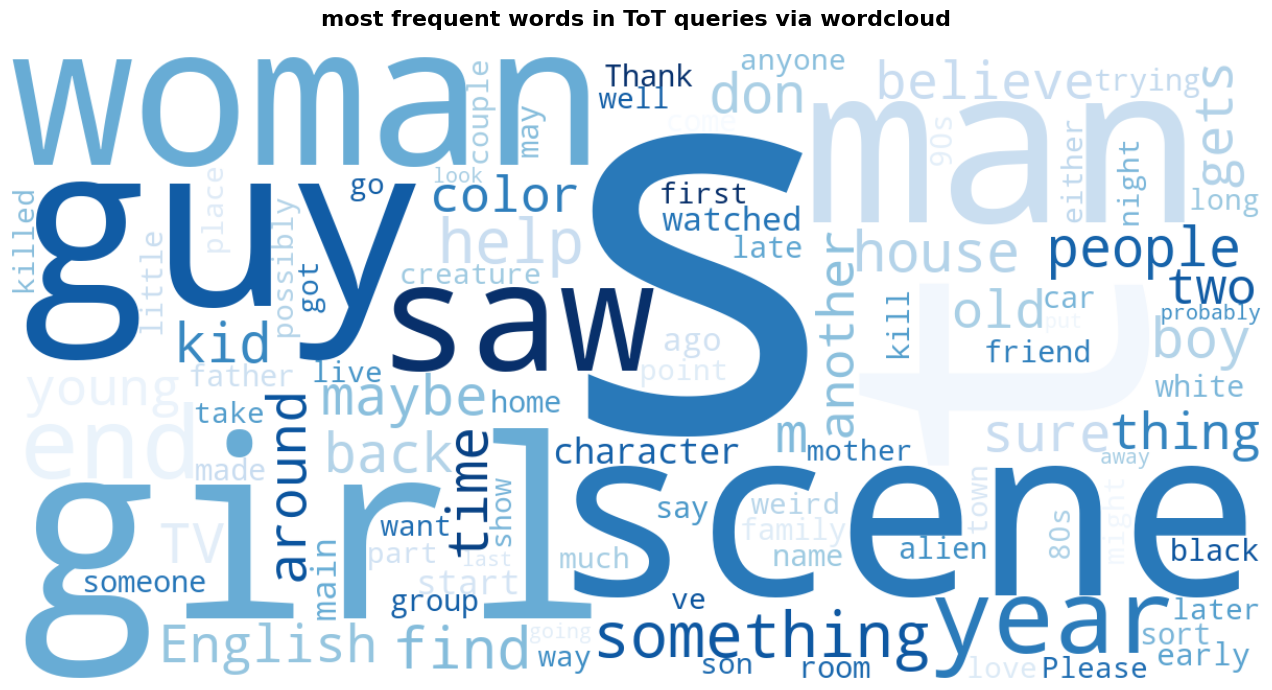

saved


In [10]:
#worldcloud for the most written words in the query sentences
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import os
from wordcloud import STOPWORDS

all_text = ''.join(df_all['text'].tolist())

#stopwords
stopwords = set(STOPWORDS)
stopwords.update(['movie', 'film', 'remember', 'think', 'know', 'one', 'like', 'really', 'seen', 'see'])

wc=WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=stopwords,
    colormap='Blues',
    max_words=100,
    collocations=False)

wc.generate(all_text)
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('most frequent words in ToT queries via wordcloud', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'wordcloud.svg'), format='svg', bbox_inches='tight')
plt.savefig(os.path.join(figures_dir, 'wordcloud.pdf'), format='pdf', bbox_inches='tight')
plt.show()
print("saved")



In [31]:
!pip install kaleido


   ---------------------------------------- 0/9 [simplejson]
   ---------------------------------------- 0/9 [simplejson]
   -------- ------------------------------- 2/9 [orjson]
   ----------------- ---------------------- 4/9 [iniconfig]
   ---------------------- ----------------- 5/9 [pytest]
   ---------------------- ----------------- 5/9 [pytest]
   ---------------------- ----------------- 5/9 [pytest]
   ---------------------- ----------------- 5/9 [pytest]
   ---------------------- ----------------- 5/9 [pytest]
   ---------------------- ----------------- 5/9 [pytest]
   -------------------------- ------------- 6/9 [choreographer]
   -------------------------- ------------- 6/9 [choreographer]
   ----------------------------------- ---- 8/9 [kaleido]
   ----------------------------------- ---- 8/9 [kaleido]
   ---------------------------------------- 9/9 [kaleido]




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import plotly.express as px
import plotly.io as pio

df_train_plot = df_train.copy()
df_train_plot['split'] = 'Train'
df_dev_plot = df_dev.copy()
df_dev_plot['split'] = 'Dev'
df_combined = pd.concat([df_train_plot, df_dev_plot], ignore_index=True)

fig = px.scatter(
    df_combined,
    x='num_sentences',
    y='num_words',
    color='split',
    hover_data=['title', 'num_words', 'num_sentences'],
    title = 'query length vs sentence count',
    labels={
        'num_sentences': 'number of sentences',
        'num_words': 'number of words',
        'split': 'split'
    },
    template='plotly_white',
    opacity=0.7
)

fig.show()

pio.write_image(fig, os.path.join(figures_dir, 'scatter.pdf'))
pio.write_image(fig, os.path.join(figures_dir, 'scatter.svg'))
print("saved")

saved


In [15]:
import plotly.graph_objects as go

fig2 = go.Figure()

fig2.add_trace(go.Histogram(
    x=df_train['num_words'],
    name='Train',
    opacity=0.7,
    marker_color='steelblue',
    nbinsx=30
))

fig2.add_trace(go.Histogram(
    x=df_dev['num_words'],
    name='Dev',
    opacity=0.7,
    marker_color='darkorange',
    nbinsx=30
))

fig2.add_trace(go.Histogram(
    x=df_test['num_words'],
    name='Test',
    opacity=0.7,
    marker_color='green',
    nbinsx=30
))

fig2.update_layout(
    barmode='overlay',
    title='Query Word Count Distribution: Train vs Dev vs Test',
    xaxis_title='Number of Words',
    yaxis_title='Frequency',
    template='plotly_white',
    legend_title='Split',
    font=dict(size=13)
)

fig2.write_html(os.path.join(figures_dir, 'histogram_splits.html'))
pio.write_image(fig2, os.path.join(figures_dir, 'histogram_splits.pdf'))
pio.write_image(fig2, os.path.join(figures_dir, 'histogram_splits.svg'))
print("saved")

saved
